In [1]:
!pip install timm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

import timm
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
# ===================== CONFIG =====================
BATCH_SIZE = 128
EPOCHS = 20
LR = 3e-4
NUM_CLASSES = 30
EPS = 1e-8

# Flatness suppression regularizer strength.
# Positive lambda → we SUBTRACT flatness from loss → optimizer is pushed AWAY from flat minima.
# Start with 0.1 and tune. Set to 0.0 to recover the baseline run.
LAMBDA_FLAT = 0.001

selected_classes = list(range(NUM_CLASSES))

In [3]:
# ===================== TRANSFORMS =====================
transform_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

transform_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
])

# ===================== DATASET FILTER =====================
def filter_dataset(dataset, selected_classes):
    targets = np.array(dataset.targets)
    mask = np.isin(targets, selected_classes)
    dataset.data = dataset.data[mask]
    dataset.targets = targets[mask].tolist()
    label_map = {cls: i for i, cls in enumerate(selected_classes)}
    dataset.targets = [label_map[t] for t in dataset.targets]
    return dataset

In [4]:
train_dataset = torchvision.datasets.CIFAR100(
    root="./data", train=True, download=True, transform=transform_train
)
test_dataset = torchvision.datasets.CIFAR100(
    root="./data", train=False, download=True, transform=transform_test
)

train_dataset = filter_dataset(train_dataset, selected_classes)
test_dataset  = filter_dataset(test_dataset,  selected_classes)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print("Train size:", len(train_dataset))
print("Test size: ", len(test_dataset))

100%|██████████| 169M/169M [00:01<00:00, 104MB/s]  


Train size: 15000
Test size:  3000


In [5]:
model = timm.create_model('vit_base_patch16_224', pretrained=True)
in_features = model.head.in_features
model.head = nn.Linear(in_features, NUM_CLASSES)
model = model.to(device)

if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs")
    model = nn.DataParallel(model)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Using 2 GPUs


In [6]:
def get_cls_features(model, x):
    """
    Extracts the CLS token embedding from the penultimate layer of the ViT.
    This is the representation space where we measure NC and flatness —
    consistent with the paper which operates on penultimate-layer features.
    """
    m = model.module if hasattr(model, "module") else model
    with torch.no_grad():
        x = m.patch_embed(x)
        cls_token = m.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        x = m.pos_drop(x + m.pos_embed)
        for blk in m.blocks:
            x = blk(x)
        x = m.norm(x)
        cls_features = x[:, 0]
    return cls_features

In [7]:
def compute_nc_metrics(features, labels, classifier_weights):
    """
    NC1: Within-class collapse. Lower = features are tightly clustered per class.
    NC2: Class means form a Simplex ETF. Lower = more symmetric geometry.
    NC3: Alignment between class means and classifier weights. Lower = more aligned.
    """
    features = features.cpu().numpy()
    labels   = labels.cpu().numpy()
    W        = classifier_weights.detach().cpu().numpy()
    K        = len(np.unique(labels))

    class_means  = np.array([np.mean(features[labels == k], axis=0) for k in range(K)])
    overall_mean = np.mean(features, axis=0)

    # NC1
    Sw = sum(np.sum((features[labels == k] - class_means[k]) ** 2) for k in range(K))
    Sb = np.sum((class_means - overall_mean) ** 2)
    nc1 = Sw / (Sb + EPS)

    # NC2
    M     = class_means - overall_mean
    M     = M / (np.linalg.norm(M, axis=1, keepdims=True) + EPS)
    G     = M @ M.T
    ETF   = np.full((K, K), -1 / (K - 1))
    np.fill_diagonal(ETF, 1)
    nc2   = np.linalg.norm(G - ETF, ord='fro')

    # NC3
    W_norm = W / (np.linalg.norm(W, axis=1, keepdims=True) + EPS)
    nc3    = np.linalg.norm(W_norm - M, ord='fro')

    return nc1, nc2, nc3

In [8]:
def compute_relative_flatness(features, logits, labels, classifier_weights):
    """
    Closed-form upper bound on relative flatness from Walter et al. (2024),
    as used in the paper. Measures trace of Hessian w.r.t. last-layer weights,
    normalized by weight norm squared.

    = E[ ||h||² · p(y|x)·(1−p(y|x)) ] / ||W||²

    Lower value → flatter loss landscape → better generalization (paper's claim).
    """
    probs         = torch.softmax(logits, dim=1)
    p_y           = probs[torch.arange(len(labels)), labels]
    curvature     = p_y * (1 - p_y)                          # per-sample curvature
    feat_norm_sq  = torch.sum(features ** 2, dim=1)           # ||h_i||²
    trace_est     = torch.mean(feat_norm_sq * curvature)      # E[||h||² · curv]
    weight_norm_sq = torch.sum(classifier_weights ** 2)
    return trace_est / (weight_norm_sq + EPS)


def flatness_regularizer(features, logits, labels, classifier_weights):
    """
    Same computation as above but kept in the compute graph (no .item()),
    so gradients flow through it during training.

    We SUBTRACT this from the loss:
        total_loss = CE_loss - lambda * flatness

    This means the optimizer sees a lower total loss when flatness is HIGH
    (sharp minima), so it is pushed AWAY from flat minima.
    This is the paper's key intervention: regularize away from flat solutions
    and observe delayed/degraded generalization.
    """
    probs          = torch.softmax(logits, dim=1)
    p_y            = probs[torch.arange(len(labels)), labels]
    curvature      = p_y * (1 - p_y)
    feat_norm_sq   = torch.sum(features ** 2, dim=1)
    trace_est      = torch.mean(feat_norm_sq * curvature)
    weight_norm_sq = torch.sum(classifier_weights ** 2)
    return trace_est / (weight_norm_sq + EPS)

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
# Weight decay kept so the only sharpness-inducing force is our explicit regularizer.

# ===================== TRACKERS =====================
nc1_hist, nc2_hist, nc3_hist = [], [], []
flatness_hist                 = []
train_acc_hist, test_acc_hist = [], []
train_loss_hist               = []          # total loss (CE + regularizer)
ce_loss_hist                  = []          # CE component only
flat_reg_hist                 = []          # regularizer component only

In [10]:
for epoch in range(EPOCHS):

    # ─────────────────────────────────────────────
    # TRAIN
    # ─────────────────────────────────────────────
    model.train()
    train_preds, train_labels_all = [], []
    total_loss_sum = 0.0
    ce_loss_sum    = 0.0
    flat_reg_sum   = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} [TRAIN]"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        # ── CLS features with grad (needed for regularizer backprop) ──
        # We re-extract features WITH gradient tracking here (not no_grad).
        m = model.module if hasattr(model, "module") else model
        with torch.no_grad():
            x = m.patch_embed(images)
            cls_token = m.cls_token.expand(x.shape[0], -1, -1)
            x = torch.cat((cls_token, x), dim=1)
            x = m.pos_drop(x + m.pos_embed)
            for blk in m.blocks:
                x = blk(x)
            x = m.norm(x)
            features = x[:, 0]   # CLS token, grad-enabled

        W = (model.module if hasattr(model, "module") else model).head.weight

        # ── Losses ──
        ce_loss  = criterion(outputs, labels)
        flat_reg = flatness_regularizer(features, outputs, labels, W)

        # Subtract flatness: push optimizer toward SHARP minima
        loss = ce_loss - LAMBDA_FLAT * flat_reg

        loss.backward()
        optimizer.step()

        total_loss_sum += loss.item()
        ce_loss_sum    += ce_loss.item()
        flat_reg_sum   += flat_reg.item()

        preds = outputs.argmax(dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels_all.extend(labels.cpu().numpy())

    train_acc = np.mean(np.array(train_preds) == np.array(train_labels_all)) * 100
    train_loss_hist.append(total_loss_sum)
    ce_loss_hist.append(ce_loss_sum)
    flat_reg_hist.append(flat_reg_sum)
    train_acc_hist.append(train_acc)

    print(f"\nEpoch {epoch+1}")
    print(f"  Total Loss : {total_loss_sum:.4f}  |  CE: {ce_loss_sum:.4f}  |  FlatReg: {flat_reg_sum:.4f}")
    print(f"  Train Acc  : {train_acc:.2f}%")

    # ─────────────────────────────────────────────
    # TEST
    # ─────────────────────────────────────────────
    model.eval()
    test_preds, test_labels_all = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Epoch {epoch+1} [TEST]"):
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            preds  = logits.argmax(dim=1)
            test_preds.extend(preds.cpu().numpy())
            test_labels_all.extend(labels.cpu().numpy())

    test_acc = np.mean(np.array(test_preds) == np.array(test_labels_all)) * 100
    test_acc_hist.append(test_acc)
    print(f"  Test Acc   : {test_acc:.2f}%")

    # ─────────────────────────────────────────────
    # NC + FLATNESS (measured on train features, no grad)
    # ─────────────────────────────────────────────
    model.eval()
    all_features, all_labels, all_logits = [], [], []

    with torch.no_grad():
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} [NC-EVAL]"):
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            feats  = get_cls_features(model, images)
            all_features.append(feats)
            all_labels.append(labels)
            all_logits.append(logits)

    all_features = torch.cat(all_features)
    all_labels   = torch.cat(all_labels)
    all_logits   = torch.cat(all_logits)

    W = (model.module if hasattr(model, "module") else model).head.weight

    nc1, nc2, nc3 = compute_nc_metrics(all_features, all_labels, W)
    flatness      = compute_relative_flatness(all_features, all_logits, all_labels, W)

    nc1_hist.append(nc1)
    nc2_hist.append(nc2)
    nc3_hist.append(nc3)
    flatness_hist.append(flatness)

    print(f"  NC1: {nc1:.6f} | NC2: {nc2:.6f} | NC3: {nc3:.6f}")
    print(f"  Flatness: {flatness:.6f}")

Epoch 1 [TRAIN]: 100%|██████████| 118/118 [06:58<00:00,  3.55s/it]



Epoch 1
  Total Loss : 368.2840  |  CE: 368.4814  |  FlatReg: 197.4819
  Train Acc  : 12.73%


Epoch 1 [TEST]: 100%|██████████| 24/24 [00:19<00:00,  1.25it/s]


  Test Acc   : 21.77%


Epoch 1 [NC-EVAL]: 100%|██████████| 118/118 [04:18<00:00,  2.19s/it]


...


Epoch 20
  Total Loss : 10.6658  |  CE: 11.9443  |  FlatReg: 1278.5227
  Train Acc  : 96.61%


Epoch 20 [TEST]: 100%|██████████| 24/24 [00:19<00:00,  1.23it/s]


  Test Acc   : 72.70%


Epoch 20 [NC-EVAL]: 100%|██████████| 118/118 [04:20<00:00,  2.21s/it]


  NC1: 605.214844 | NC2: 6.299980 | NC3: 3.203428
  Flatness: 8.503427


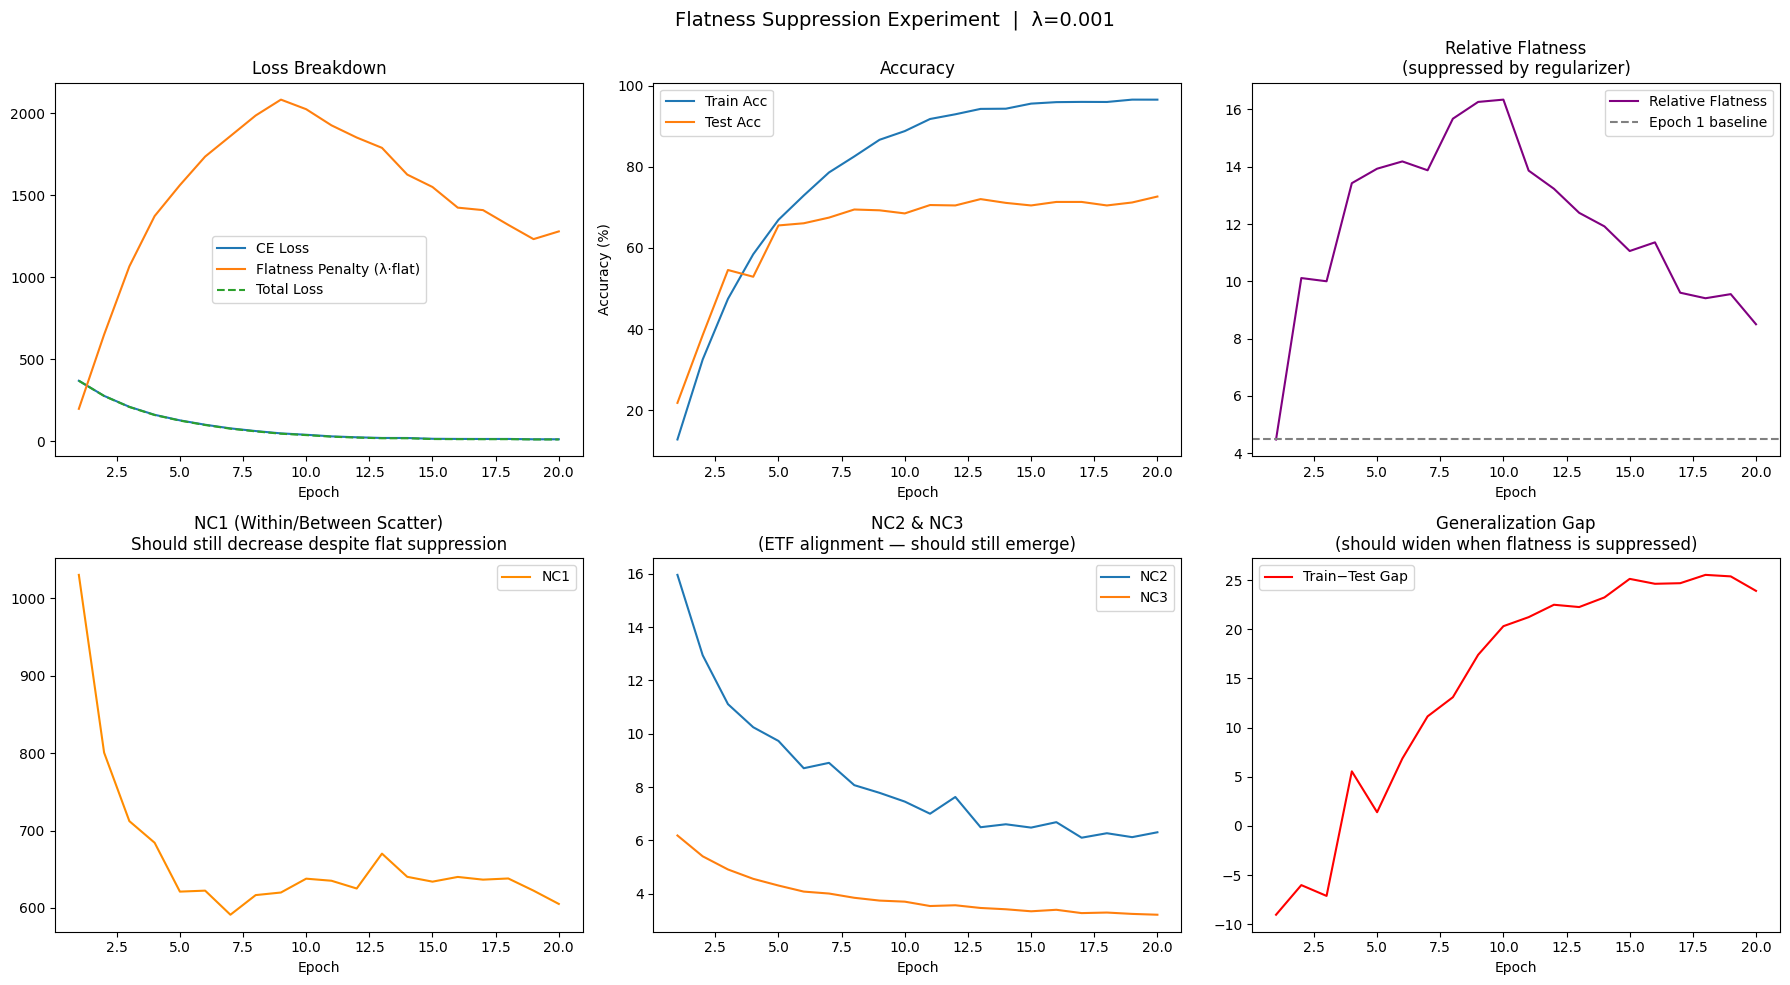

In [4]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(18, 10))

# ── Total loss breakdown ──
plt.subplot(2, 3, 1)
plt.plot(epochs_range, ce_loss_hist,    label="CE Loss")
plt.plot(epochs_range, flat_reg_hist,   label="Flatness Penalty (λ·flat)")
plt.plot(epochs_range, train_loss_hist, label="Total Loss", linestyle='--')
plt.title("Loss Breakdown")
plt.xlabel("Epoch")
plt.legend()

# ── Accuracy ──
plt.subplot(2, 3, 2)
plt.plot(epochs_range, train_acc_hist, label="Train Acc")
plt.plot(epochs_range, test_acc_hist,  label="Test Acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

# ── Flatness ──
plt.subplot(2, 3, 3)
plt.plot(epochs_range, [f.cpu().item() if torch.is_tensor(f) else f for f in flatness_hist], label="Relative Flatness", color='purple')
plt.axhline(y=flatness_hist[0].cpu().item() if torch.is_tensor(flatness_hist[0]) else flatness_hist[0], linestyle='--', color='gray', label="Epoch 1 baseline")  
plt.title("Relative Flatness\n(suppressed by regularizer)")
plt.xlabel("Epoch")
plt.legend()

# ── NC1 ──
plt.subplot(2, 3, 4)
plt.plot(epochs_range, nc1_hist, label="NC1", color='darkorange')
plt.title("NC1 (Within/Between Scatter)\nShould still decrease despite flat suppression")
plt.xlabel("Epoch")
plt.legend()

# ── NC2 & NC3 ──
plt.subplot(2, 3, 5)
plt.plot(epochs_range, nc2_hist, label="NC2")
plt.plot(epochs_range, nc3_hist, label="NC3")
plt.title("NC2 & NC3\n(ETF alignment — should still emerge)")
plt.xlabel("Epoch")
plt.legend()

# ── Train-Test Gap ──
plt.subplot(2, 3, 6)
gap = [tr - te for tr, te in zip(train_acc_hist, test_acc_hist)]
plt.plot(epochs_range, gap, label="Train−Test Gap", color='red')
plt.title("Generalization Gap\n(should widen when flatness is suppressed)")
plt.xlabel("Epoch")
plt.legend()

plt.suptitle(f"Flatness Suppression Experiment  |  λ={LAMBDA_FLAT}", fontsize=14)
plt.tight_layout()
plt.show()